In [95]:
import iisignature
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, SparsePCA

In [96]:
# Ensure the project root is in the Python path for module imports
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from cd_poly.cd_poly import *

In [97]:
def gen(t, amp, freq, phase, damping):
    return np.column_stack([t, amp * np.sin(freq * t + phase) * np.exp(-damping * t)])

(-2.5, 2.5)

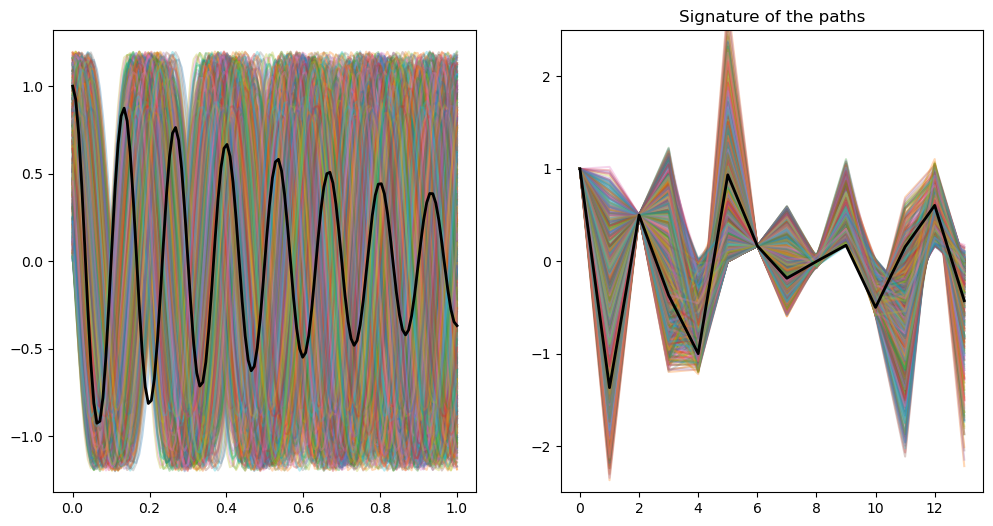

In [99]:
d = 3
sig_d = d

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
t = np.linspace(0, 1, 128)

sigs = []

for i in range(1000):
    path = gen(t, 
               np.random.uniform(0.8, 1.2),
               np.random.uniform(9., 11.) * np.pi, 
               np.random.uniform(0., np.pi), 
               0.)
    sig = iisignature.sig(path, sig_d)
    sigs.append(sig)
    ax[0].plot(t, path[:,1], alpha=0.3)
    ax[1].plot(sig, alpha=0.3)

path = gen(t, 1., 15 * np.pi, np.pi/2, 1.)
sig_out = iisignature.sig(path, sig_d)
ax[0].plot(t, path[:,1], color='black', lw=2)
ax[1].plot(sig_out, color='black', lw=2)
ax[1].set_title('Signature of the paths')
ax[1].set_ylim(-2.5, 2.5)


In [100]:
sigs = np.array(sigs)
sigs.shape

(1000, 14)

In [101]:
pca = PCA(n_components=4)
pca.fit(sigs)

PCA(n_components=4)

In [102]:
pcas = pca.transform(sigs)
pcas.shape

(1000, 4)

In [103]:
pca_out = pca.transform(sig_out.reshape(1, -1))
pca_out.shape

(1, 4)

In [ ]:
sigs = np.array(sigs)
sigs.shape

(1000, 14)

In [ ]:
pca = PCA(n_components=4)
pca.fit(sigs)

PCA(n_components=4)

In [ ]:
pcas = pca.transform(sigs)
pcas.shape

(1000, 4)

In [ ]:
pca_out = pca.transform(sig_out.reshape(1, -1))
pca_out.shape

(1, 4)

In [104]:
p = CDPolynomial(pcas, degree=4, eps=1e-6)
p.moments.shape

(70, 70)

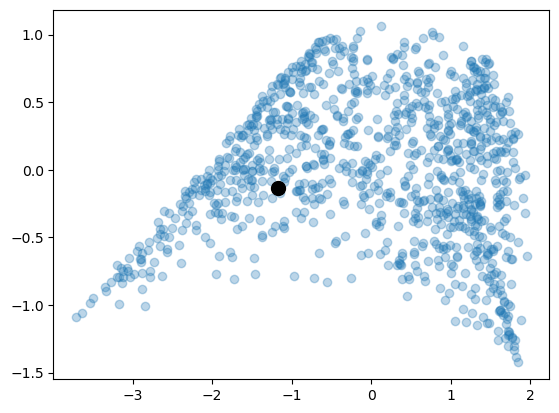

In [105]:
fig, ax = plt.subplots()
ax.scatter(pcas[:, 0], pcas[:, 1], alpha=0.3)
ax.scatter(pca_out[:, 0], pca_out[:, 1], color='black', s=100, label='outlier')
if pca.n_components == 2:
    p.plot(ax, multiplier=0.3)

In [106]:
np.quantile(p(pcas), .8), p(pca_out)

(np.float64(71.81139510330424), array([2067.9307604]))

In [94]:
# what's the CD polynomial of a random walk?
noise = np.random.normal(size=128).cumsum() / np.sqrt(128)
s = iisignature.sig(np.column_stack([t, noise]), sig_d).reshape(1, -1)
p(pca.transform(s))

array([3379.45982505])

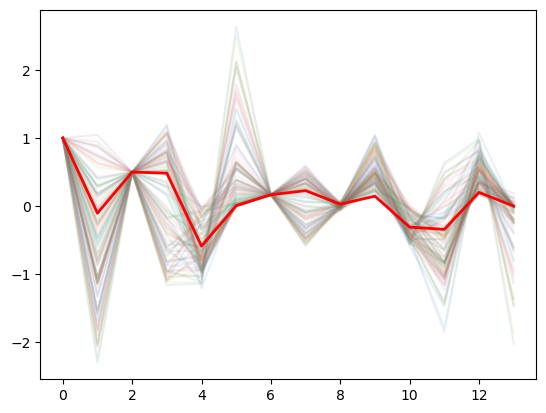

In [89]:
plt.plot(sigs[:100].T, alpha=.1);
plt.plot(s.T, color='red', lw=2);

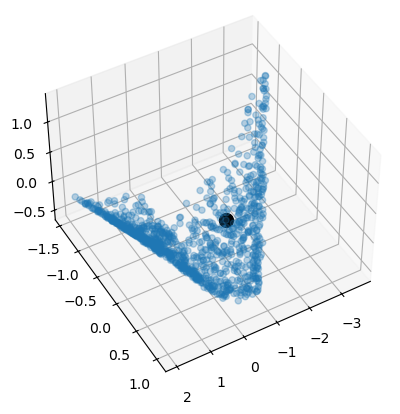

In [90]:
if d == 3:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pcas[:, 0], pcas[:, 1], pcas[:, 2], alpha=0.3)
    ax.scatter(pca_out[:, 0], pca_out[:, 1], pca_out[:, 2], color='black', s=100, label='outlier')
    ax.view_init(elev=45, azim=60)
    plt.show()

In [851]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()

In [856]:
sigs.shape

(1000, 14)

In [857]:
p(pcas).shape

(1000,)

In [858]:
lm.fit(sigs, p(pcas))

LinearRegression()

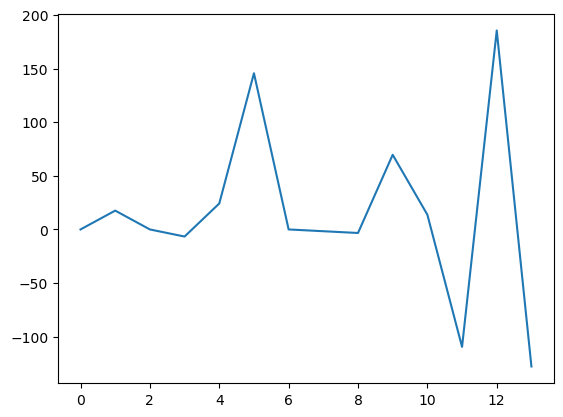

In [867]:
plt.plot(lm.coef_)

## Real example

In [589]:
from simulation.gen_pend import *
from scipy import stats

param_dists = {
    'q': stats.uniform(-np.pi, 2 * np.pi),
    'v': stats.norm(loc=0, scale=0),
    'b': stats.expon(loc=0, scale=0)
}

times, trajs = gen_trajs(10_000, 5., 64, param_dists)
trajs.shape

_, traj_ood = gen_one_traj(5., 64, np.pi/4, 5., 0.3)

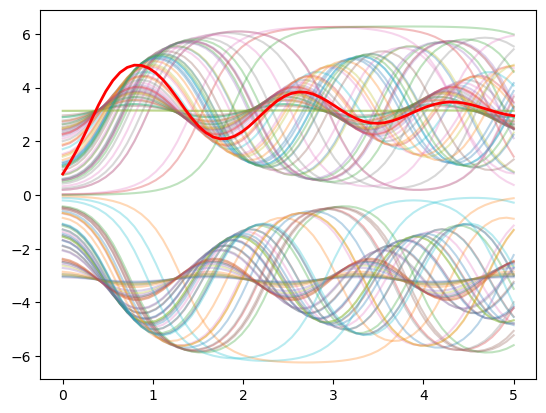

In [5]:
fig, ax = plt.subplots()
for i in range(100):
    ax.plot(times, trajs[i, 0], alpha=0.3)
ax.plot(times, traj_ood[0, 0], color='red', lw=2, label='outlier')

In [622]:
def to_sincos(trajs):
    sincos = np.concatenate((np.sin(trajs[:, :1]),
                             np.cos(trajs[:, :1])),
                             axis=1)
    return np.concatenate((sincos, trajs[:, 1:]), axis=1)

X = to_sincos(trajs)

In [61]:
sig_d = 3 # should be too high
n_pca = 3 # shouldn't be too low
cd_d = 5 # shouldn't be too low

In [62]:
sigs = []
for traj in X:
    sig = iisignature.sig(traj.T, sig_d)
    sigs.append(sig)

In [63]:
sigs = np.array(sigs)

In [64]:
sigs.shape

(10000, 39)

In [65]:
pca = PCA(n_components=n_pca)
pcas = pca.fit_transform(sigs)

In [66]:
sig_out = iisignature.sig(to_sincos(traj_ood)[0].T, sig_d)
pca_out = pca.transform(sig_out.reshape(1, -1)).reshape(1, -1)

In [67]:
pca_out

array([[-13.21651014,  50.0852689 ,  24.52466888]])

In [68]:
p = CDPolynomial(pcas, degree=cd_d)

In [69]:
if n_pca == 2:
    fig, ax = plt.subplots()
    ax.scatter(pcas[:, 0], pcas[:, 1], alpha=0.3)
    ax.scatter(pca_out[:, 0], pca_out[:, 1], color='black', s=100, label='outlier')
    p.plot(ax, multiplier=0.3)

In [70]:
p(pcas).max(), p(pca_out)

(np.float64(704.3322842444668), array([7149.15989673]))

In [ ]:
p.moments.shape

(56, 56)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D # This is the key for 3D plots

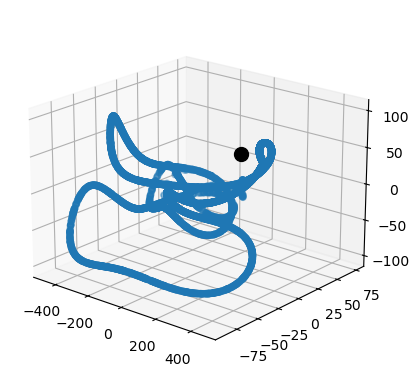

In [ ]:
if n_pca == 3:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pcas[:, 0], pcas[:, 1], pcas[:, 2], alpha=0.3)
    ax.scatter(pca_out[:, 0], pca_out[:, 1], pca_out[:, 2], color='black', s=100, label='outlier')
    ax.view_init(elev=20, azim=-50)
    plt.show()
    

## Monte Carlo approach: sampling path signature features

[120  28]


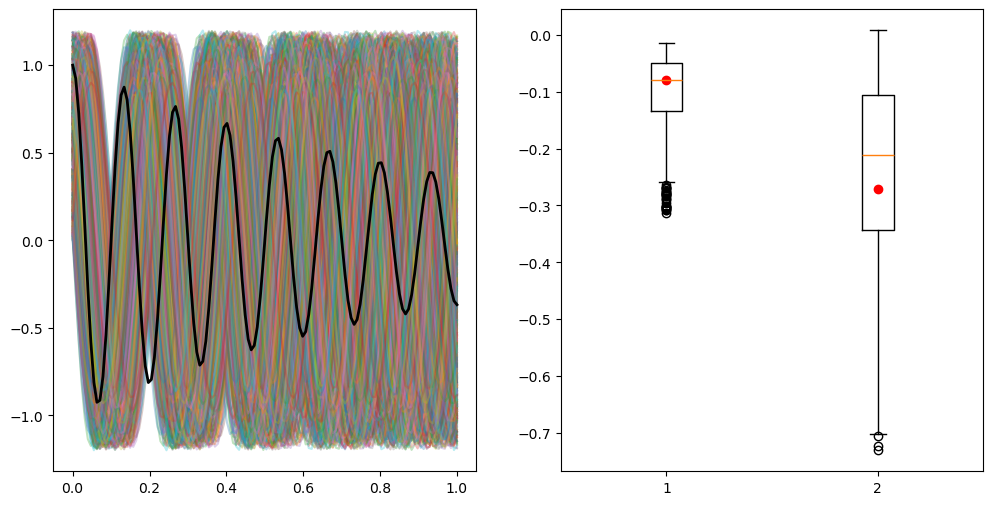

In [585]:
sig_d = 7
n_features = 2

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
t = np.linspace(0, 1, 128)

sigs = []

for i in range(1000):
    path = gen(t, 
               np.random.uniform(0.8, 1.2),
               np.random.uniform(9., 11.) * np.pi, 
               np.random.uniform(0., np.pi), 
               0.)
    sig = iisignature.sig(path, sig_d)
    sigs.append(sig)
    ax[0].plot(t, path[:,1], alpha=0.3)

path = gen(t, 1., 15 * np.pi, np.pi/2, 1.)
sig_out = iisignature.sig(path, sig_d)

ps_idx = np.random.choice(range(len(sig_out)), size=n_features, replace=False)

sigs = np.array(sigs)
sigs = sigs[:, ps_idx]
sig_out = sig_out[ps_idx]

ax[0].plot(t, path[:,1], color='black', lw=2)

ax[1].boxplot(sigs)
ax[1].scatter(range(1, n_features + 1), sig_out, color='red')

print(ps_idx)

In [586]:
deg = 6
p = CDPolynomial(sigs, degree=deg, eps=1e-18)
p.moments.shape

(28, 28)

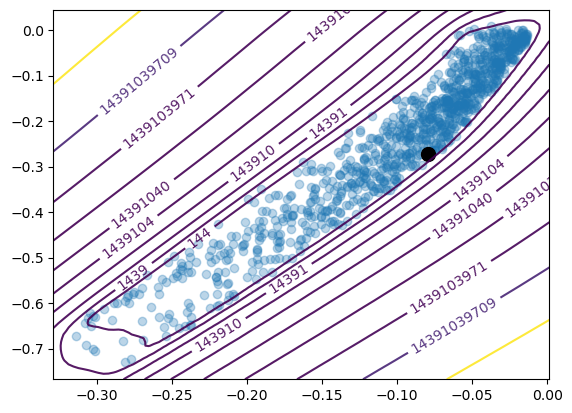

In [587]:
if n_features == 2:
    fig, ax = plt.subplots()
    ax.scatter(sigs[:, 0], sigs[:, 1], alpha=0.3)
    ax.scatter(sig_out[0], sig_out[1], color='black', s=100, label='outlier')
    p.plot(ax, multiplier=0.3)

In [583]:
if n_features == 3:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(sigs[:, 0], sigs[:, 1], sigs[:, 2], alpha=0.3)
    ax.scatter(sig_out[0], sig_out[1], sig_out[2], color='black', s=100, label='outlier')
    ax.view_init(elev=10, azim=-50)
    plt.show()

In [588]:
# NB: reg param of CD poly greatly influences its values; if too large, can fail to detect outliers
np.quantile(p(sigs), .8), p(sig_out.reshape(1, -1))

(np.float64(29.21550003705287), array([18.74009364]))

Is there a data-dependent way to decide how well the CD level set fits the data?

Some ideas:
- throw out any randomly sampled features that are uninformative, i.e. where most values are close to zero ?
- choose the CD degree in an adaptive way: start low, and if it fails to detect an outlier, increase

## Monte Carlo approach on sim trajectories

In [957]:
n_sim = 1000

param_dists = {
    'q': stats.uniform(-np.pi, 2 * np.pi),
    'v': stats.norm(loc=0, scale=1.),
    'b': stats.expon(loc=0, scale=0.01)
}

times, trajs = gen_trajs(n_sim, 5., 128, param_dists)
trajs.shape

_, traj_ood = gen_one_traj(5., 128, np.pi/4, 10., 0.8)

trajs_sc = to_sincos(trajs)
traj_ood_sc = to_sincos(traj_ood)

In [958]:
paths = np.zeros((n_sim, 3, 128))
path_ood = np.zeros((3, 128))

paths[:, 0] = times
path_ood[0] = times

paths[:, 1:] = trajs_sc[:, :2]
path_ood[1:] = traj_ood_sc[:, :2]

[1 0 2]


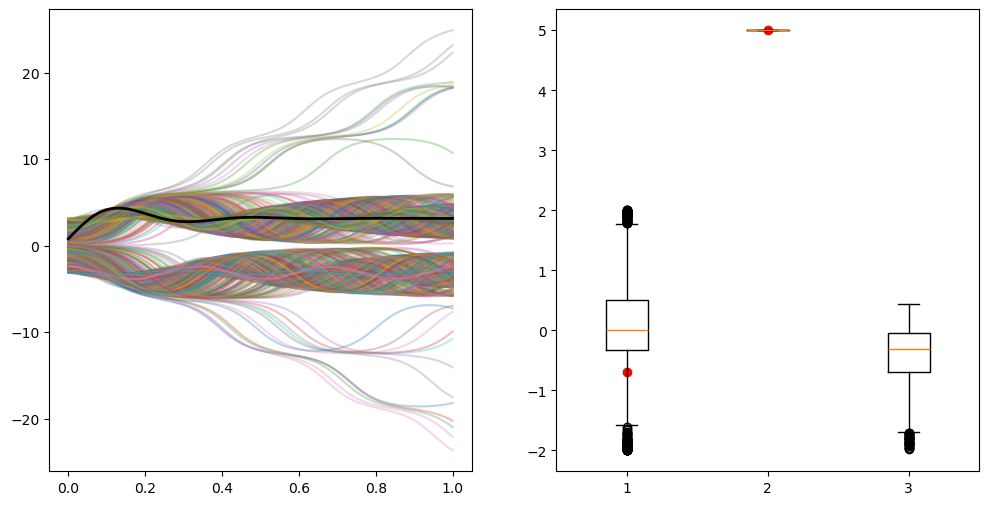

In [959]:
sig_d = 5
n_features = 3

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sigs = []

for i in range(n_sim):
    path = paths[i].T
    sig = iisignature.sig(path, sig_d)
    sigs.append(sig)
    ax[0].plot(t, trajs[i, 0], alpha=0.3)

path = path_ood.T
sig_out_all = iisignature.sig(path, sig_d)

ps_idx = np.random.choice(range(len(sig_out)), size=n_features, replace=False)

sigs_all = np.array(sigs)
sigs = sigs_all[:, ps_idx]
sig_out = sig_out_all[ps_idx]

ax[0].plot(t, traj_ood[0, 0], color='black', lw=2)

ax[1].boxplot(sigs)
ax[1].scatter(range(1, n_features + 1), sig_out, color='red')

print(ps_idx)

In [960]:
deg = 4
p = CDPolynomial(sigs, degree=deg, eps=1e-3)
p.moments.shape

(35, 35)

In [961]:
if n_features == 2:
    fig, ax = plt.subplots()
    ax.scatter(sigs[:, 0], sigs[:, 1], alpha=0.3)
    ax.scatter(sig_out[0], sig_out[1], color='black', s=100, label='outlier')
    p.plot(ax, multiplier=0.3)

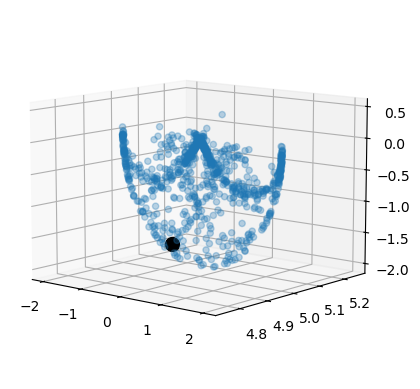

In [962]:
if n_features == 3:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(sigs[:, 0], sigs[:, 1], sigs[:, 2], alpha=0.3)
    ax.scatter(sig_out[0], sig_out[1], sig_out[2], color='black', s=100, label='outlier')
    ax.view_init(elev=10, azim=-50)
    plt.show()

In [963]:
# NB: reg param of CD poly greatly influences its values; if too large, can fail to detect outliers
quant = np.quantile(p(sigs), .8)
out = p(sig_out.reshape(1, -1))[0]
print(f'quantile of CD values: {quant}   CD value of outlier: {out}')
if out > quant:
    print('Reject')
else:
    print('Accept')

quantile of CD values: 22.188689685793097   CD value of outlier: 29.375377139828743
Reject


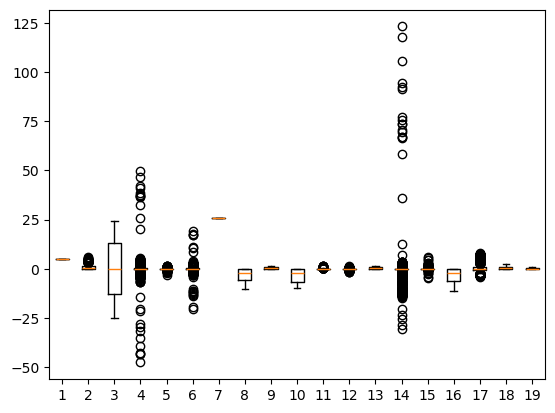

In [964]:
plt.boxplot(sigs_all[:, ::20]);

In [965]:
from sklearn.decomposition import TruncatedSVD

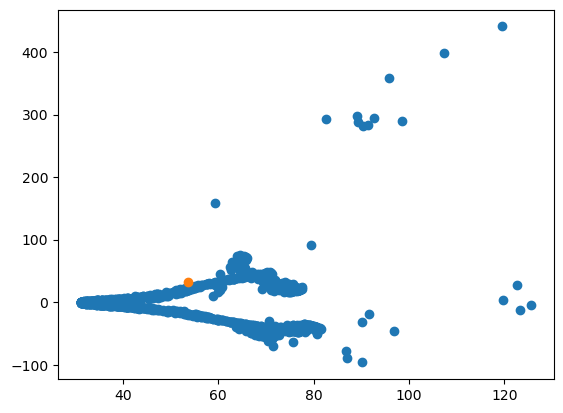

In [967]:
model = TruncatedSVD()
plt.scatter(*model.fit_transform(sigs_all).T)
plt.scatter(*model.transform(sig_out_all.reshape(1, -1)).T)